<center>
<h2><b>A Hybrid GWO and GAPSO Optimized Approach for Heart-Disease Prediction By RF and XGB Classifier</b></h2>
<h3><b>Final Project – Applied Quantitative Logistics</b></h3>

<hr style="width:60%;">

<h4><b>By: Salman Hussain & Amit Raj</b></h4>

<hr style="width:60%;">
</center>


### **Introduction**

This project aims to improve heart disease prediction by implementing **hybrid metaheuristic optimization techniques** for feature selection. We use two popular evolutionary methods:

- **GAPSO** – A hybrid of Genetic Algorithm (GA) and Particle Swarm Optimization (PSO)  
- **GWO** – Grey Wolf Optimizer

The selected features are evaluated using two powerful classifiers:

- **Random Forest (RF)** – A robust ensemble method  
- **XGBoost (XGB)** – A highly efficient boosting algorithm

We apply our approach on two benchmark datasets: **Cleveland** and **Statlog**, performing comparative analysis based on the following metrics:

$$
\text{Accuracy},\quad \text{Precision},\quad \text{Recall},\quad \text{F1-score},\quad \text{AUC}
$$

### **Step 1: Import Required Libraries**

In this step, we import all necessary Python libraries to perform:

- Data analysis  
- Preprocessing  
- Modeling  
- Optimization  
- Evaluation

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from scipy.stats import ttest_rel
import time as tm
import random
import math

##**Step 2: Load and Preprocess Datasets**

In this step, we load two benchmark datasets — **Cleveland** and **Statlog** — for heart disease prediction, and perform essential preprocessing steps:

- **Column Renaming**: Both datasets are aligned to have consistent column names.

- **Binary Classification Target**: The target field is binarized:
  - `0` = No heart disease  
  - `1` = Presence of heart disease (any non-zero class)

- **Class Distribution Check**: Ensures class balance between healthy and diseased instances.

- **Min-Max Normalization**: Scales all feature values to the range:

  $$
  [0, 1]
  $$

  This standardization improves the performance of optimization algorithms.

In [ ]:
#Load and preprocess dataset
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
cleveland_df = pd.read_csv("Heart_disease_cleveland_new.csv")
statlog_df = pd.read_csv("Heart_disease_statlog.csv")
cleveland_df.columns = columns
statlog_df.columns = columns
cleveland_df['target'] = (cleveland_df['target'] > 0).astype(int)
statlog_df['target'] = (statlog_df['target'] > 0).astype(int)

#Validate class counts
cleveland_class_counts = cleveland_df['target'].value_counts().sort_index()
statlog_class_counts = statlog_df['target'].value_counts().sort_index()

#Normalize using MinMaxScaler
scaler = MinMaxScaler()
cleveland_df[columns[:-1]] = scaler.fit_transform(cleveland_df[columns[:-1]])
statlog_df[columns[:-1]] = scaler.fit_transform(statlog_df[columns[:-1]])

### **Step 3: Visualizing Class Distributions**

This step visualizes the balance between **healthy** and **diseased** patients in both datasets — **Cleveland** and **Statlog** — to ensure fair model training and evaluation.


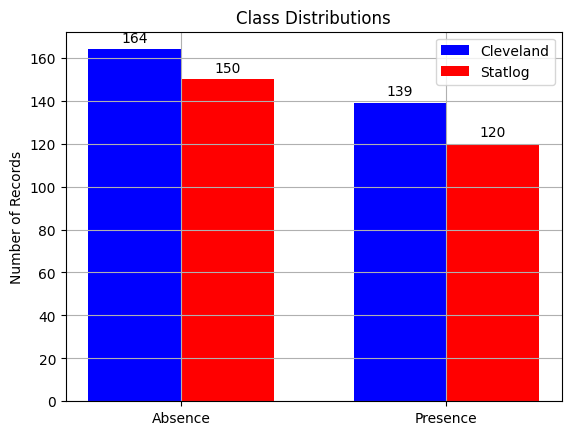

In [ ]:
#Class Distribution
labels = ['Absence', 'Presence']
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, [cleveland_class_counts[0], cleveland_class_counts[1]], width, label='Cleveland', color='blue')
bar2 = ax.bar(x + width/2, [statlog_class_counts[0], statlog_class_counts[1]], width, label='Statlog', color='red')
ax.set_ylabel('Number of Records')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.title("Class Distributions")
plt.grid(True)
plt.show()

### **Explanation**

This bar chart displays the count of samples with and without heart disease (`target = 1` vs `0`) in both datasets.

Balanced datasets help reduce bias in classifier learning. We observe:

- **Cleveland**: 164 absence vs. 139 presence  
- **Statlog**: 150 absence vs. 120 presence

This confirms that both datasets are **moderately balanced**, allowing fair comparisons during model evaluation.

### **Step 4: Statistical Analysis & Feature Distribution Summary**

To better understand the role of each feature in distinguishing between patients with and without heart disease, we perform **descriptive statistical analysis** grouped by the target variable:

- `0` = Healthy  
- `1` = Diseased

In [ ]:
#Statistical Analysis & Feature Importance Evaluation
def summary_stats(df):
    stats_1 = df[df['target'] == 1].describe().T[['mean', 'std']]
    stats_0 = df[df['target'] == 0].describe().T[['mean', 'std']]
    return stats_1, stats_0
cleveland_stats_1, cleveland_stats_0 = summary_stats(cleveland_df)
statlog_stats_1, statlog_stats_0 = summary_stats(statlog_df)
print("Stats (Target = 1) ===")
print("Cleveland:")
print(cleveland_stats_1)
print("\nStatlog:")
print(statlog_stats_1)
print(" Stats (Target = 0) ===")
print("Cleveland:")
print(cleveland_stats_0)
print("\nStatlog:")
print(statlog_stats_0)

Stats (Target = 1) ===
Cleveland:
              mean       std
age       0.575540  0.165384
sex       0.820144  0.385457
cp        0.863309  0.274560
trestbps  0.382720  0.177066
chol      0.286472  0.112984
fbs       0.158273  0.366317
restecg   0.586331  0.488743
thalach   0.521061  0.172467
exang     0.546763  0.499609
oldpeak   0.253887  0.210094
slope     0.413669  0.281868
ca        0.376499  0.340111
thal      0.683453  0.442915
target    1.000000  0.000000

Statlog:
              mean       std
age       0.574826  0.169089
sex       0.833333  0.374241
cp        0.872222  0.259941
trestbps  0.381525  0.180146
chol      0.297869  0.109519
fbs       0.141667  0.350170
restecg   0.612500  0.487070
thalach   0.518003  0.176570
exang     0.550000  0.499580
oldpeak   0.255511  0.206785
slope     0.408333  0.282422
ca        0.383333  0.344762
thal      0.691667  0.445252
target    1.000000  0.000000
 Stats (Target = 0) ===
Cleveland:
              mean       std
age       0.491362  0.

### **Explanation**

This analysis computes **mean** and **standard deviation (std)** for each feature, separated by disease status (`target`).

It helps identify which features show significant shifts in value distributions between **diseased** and **healthy** individuals.


### **Key Observations**

| **Feature** | **Disease Present (↑)** | **Disease Absent (↓)** | **Trend** |
|-------------|--------------------------|--------------------------|------------|
| `oldpeak`   | Mean ~0.25 (more ST depression) | Mean ~0.09 (less ST depression) | ↑ |
| `thalach`   | Mean ~0.52 (lower max HR)       | Mean ~0.66 (higher max HR)      | ↓ |
| `cp` (chest pain) | Higher (~0.86)           | Lower (~0.59)                   | ↑ |
| `ca`, `thal` | Larger means in diseased group | Very low in healthy group       | ↑ |


These differences suggest that **`oldpeak`**, **`thalach`**, **`cp`**, **`ca`**, and **`thal`** are potentially strong discriminative features for heart disease prediction.


### **Step 5: T² Metric Calculation and Feature Correlation Analysis**

To identify the most discriminative features for heart disease classification, we use **Hotelling’s T² metric**.

This metric evaluates how well each feature **separates the two classes**:

- **Presence of disease** (`target = 1`)
- **Absence of disease** (`target = 0`)

In [ ]:
#T² Metric Calculation to evaluate feature discriminative power
def compute_t2(df):
    df1 = df[df['target'] == 1]
    df0 = df[df['target'] == 0]
    n1, n0 = len(df1), len(df0)
    t2_data = []
    for col in df.columns[:-1]:
        x1, s1 = df1[col].mean(), df1[col].std()
        x0, s0 = df0[col].mean(), df0[col].std()
        sp = (((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2))
        t2 = ((x1 - x0) ** 2) / (sp * (1 / n1 + 1 / n0)) if sp > 0 else 0
        t2_data.append((col, sp, x1 - x0, t2))
    return pd.DataFrame(t2_data, columns=['Feature', 'Sp', 'Delta', 'T2']).sort_values(by='T2', ascending=False)

cleveland_t2 = compute_t2(cleveland_df)
statlog_t2 = compute_t2(statlog_df)
print("\nT² Metric for Cleveland:")
print(cleveland_t2)
print("\nT² for Statlog:")
print(statlog_t2)

#Correlation analysis
cleveland_corr = cleveland_df[['cp', 'slope', 'ca', 'thal', 'exang']].corr()
statlog_corr = statlog_df[['cp', 'slope', 'ca', 'exang', 'oldpeak']].corr()
print("\n Correlation Cleveland:")
print(cleveland_corr)
print("\n Correlation Statlog:")
print(statlog_corr)


T² Metric for Cleveland:
     Feature        Sp     Delta          T2
12      thal  0.168479  0.494429  109.163583
11        ca  0.076731  0.287068   80.800610
8      exang  0.180134  0.406519   69.020891
9    oldpeak  0.028846  0.159277   66.166707
7    thalach  0.025269 -0.145947   63.419223
2         cp  0.085115  0.265748   62.423779
10     slope  0.084289  0.209401   39.138194
1        sex  0.202305  0.259168   24.978872
0        age  0.033806  0.084178   15.769637
6    restecg  0.241205  0.168648    8.871394
3   trestbps  0.027030  0.050173    7.006632
4       chol  0.013919  0.020170    2.199054
5        fbs  0.127217  0.018029    0.192237

T² for Statlog:
     Feature        Sp     Delta          T2
12      thal  0.167407  0.505000  101.559048
11        ca  0.078762  0.287778   70.098369
8      exang  0.183483  0.396667   57.169619
7    thalach  0.025890 -0.148664   56.909111
9    oldpeak  0.028263  0.155081   56.729134
2         cp  0.083129  0.265556   56.554610
10     slope

### **Explanation**

- #### **T² Metric**

The T² score ranks features by their ability to distinguish between patients with and without heart disease.  
A **higher T²** indicates greater class separation.

| **Top Features (Cleveland)** | **T² Value** | **Interpretation**                     |
|------------------------------|--------------|----------------------------------------|
| `thal`                       | 109.16       | Strong class separator                 |
| `ca`                         | 80.80        | Vessel count is significant            |
| `exang`                      | 69.02        | Exercise-induced angina                |
| `oldpeak`                    | 66.17        | ST depression severity                 |
| `thalach`                    | 63.42        | Max heart rate achieved                |

Similar trends are seen in the **Statlog** dataset, confirming the **robustness** of selected features across datasets.

- #### **Correlation Matrix**

  - **Cleveland** shows strong positive correlation between `exang` and features like `thal`, `cp`, and `slope`.
  - **Statlog** reveals high correlation between `slope` and `oldpeak` (**0.60**), suggesting **multicollinearity**.


- #### **Why it Matters**

  Highly correlated features may lead to **redundancy**.  
  During optimization using **GAPSO** or **GWO**, such overlapping features may be:

  - **Reduced**
  - **Penalized**

This helps prevent **overfitting** and enhances model **generalization**.

### **Step 6: Hybrid Feature Selection using GAPSO**

This section defines the core components of the **GAPSO algorithm** — a hybrid of **Genetic Algorithm (GA)** and **Particle Swarm Optimization (PSO)** — designed to select the most relevant features for heart disease classification.

###  **Genetic Algorithm (GA) Components**

- **`initialize_population(size, n)`**  
   Creates an initial population of chromosomes, where each chromosome is a binary array of length `n` representing selected features.

- **`crossover(p1, p2)`**  
   Performs single-point crossover between two parent chromosomes using a random binary mask to mix their genes.

- **`mutate(chrom, mutation_probs)`**  
   Applies mutation to each gene in a chromosome with a probability defined per feature (lower for high-importance features).


###  **Fitness Functions**

These functions evaluate how well a chromosome (feature subset) performs in classifying heart disease using **cross-validated accuracy**:

- **`fitness_rf(X, y, chrom)`**  
   Uses a **Random Forest** classifier to compute the fitness score. If no features are selected, the score is zero.

- **`fitness_xgb(X, y, chrom)`**  
   Uses an **XGBoost** classifier to compute the score in the same way. Supports log-loss evaluation.


These components form the foundation of the **GAPSO optimization process**. They are used iteratively during the search for optimal feature subsets, guiding the algorithm toward high-performing models with fewer, more relevant features.

In [ ]:
# Hybrid Feature Selection using GAPSO
# Genetic Algorithm (GA) Components
def initialize_population(size, n):
    #Each chromosome is a binary string of length n
    return np.random.randint(0, 2, size=(size, n))

def crossover(p1, p2):
    #Single-point crossover
    mask = np.random.rand(len(p1)) > 0.5
    return np.where(mask, p1, p2)

def mutate(chrom, mutation_probs):
    #Mutate each gene based on its corresponding mutation probability
    for i in range(len(chrom)):
        if np.random.rand() < mutation_probs[i]:
            chrom[i] = 1 - chrom[i]
    return chrom

# Fitness function using RandomForest
def fitness_rf(X, y, chrom):
    if np.sum(chrom) == 0:
        return 0
    features = X.columns[chrom == 1]
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(model, X[features], y, cv=3, scoring='accuracy')
    return np.mean(scores)

# Fitness function using XGBoost
def fitness_xgb(X, y, chrom):
    if np.sum(chrom) == 0:
        return 0
    features = X.columns[chrom == 1]
    model = XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42)
    scores = cross_val_score(model, X[features], y, cv=3, scoring='accuracy')
    return np.mean(scores)

### **Particle Swarm Optimization (PSO) Components**

In this step, we define the **PSO component** of the **GAPSO hybrid algorithm**.  
PSO is inspired by the behavior of swarms (e.g., birds or fish) and is used here to refine feature selection by updating binary chromosomes based on **personal and global knowledge**.

Each **Particle** represents a candidate solution (feature subset), and its **position** is updated iteratively to explore new combinations.

- ###  **Key Concepts in PSO**

  - **Swarm Initialization**  
    Generates a population of particles, where each particle is a binary vector representing a feature subset.

  - **Velocity Update**  
    Balances three forces:
    - **Inertia** (maintains previous direction)
    - **Personal Best** (exploration of own success)
    - **Global Best** (exploitation of swarm knowledge)

  - **Sigmoid Function**  
    Converts the velocity values into probabilities.  
    These probabilities determine whether a bit (feature) flips from `0 → 1` or `1 → 0`.

  - **Mutation**  
    Ensures **diversity** in the swarm.  
    Helps prevent premature convergence and avoids **local optima**, which is especially critical in binary feature selection tasks.

Together, these mechanisms allow the PSO component to **search intelligently** within the binary feature space, contributing to the overall power and adaptability of the GAPSO optimization strategy.

In [ ]:
#Particle Swarm Optimization (PSO) Components
class Particle:
    def __init__(self, position):
        self.position = position
        self.velocity = np.zeros_like(position)
        self.best_position = position.copy()
        self.best_fitness = -np.inf

def initialize_swarm(size, n):
    #Initialize a list of particles each with a random binary position
    return [Particle(initialize_population(1, n)[0]) for _ in range(size)]

def update_velocity(particle, global_best, w=0.7, c1=1.5, c2=1.5):
    #Update velocity based on personal best and global best
    r1, r2 = np.random.rand(2)
    cognitive = c1 * r1 * (particle.best_position - particle.position)
    social = c2 * r2 * (global_best - particle.position)
    particle.velocity = w * particle.velocity + cognitive + social

def update_position(particle, mutation_probs):
    #Use a sigmoid function to update position probabilistically
    sigmoid_velocity = 1 / (1 + np.exp(-particle.velocity))
    particle.position = np.where(np.random.rand(len(particle.position)) < sigmoid_velocity,
                                 1 - particle.position,
                                 particle.position)
    #Apply mutation to further refine the particles feature subset
    particle.position = mutate(particle.position, mutation_probs)

### **Step 7: Running the Full GAPSO Optimization Loop**

This step executes the **complete GAPSO feature selection process**, combining the strengths of **Genetic Algorithm (GA)** and **Particle Swarm Optimization (PSO)** to identify optimal feature subsets for classification.


###  **Function: `run_gapso()`**

A general-purpose function that runs GAPSO using either a **Random Forest** or **XGBoost** fitness evaluator.

#### **Key Parameters**:
- `X`, `y`: Feature matrix and target labels  
- `t2_scores`: Ranked features based on Hotelling’s T² metric  
- `fitness_fn`: Fitness evaluator (`fitness_rf` or `fitness_xgb`)  
- `gens`: Number of generations  
- `pop_size`: Total population size (split equally between GA and PSO)  
- `dataset_name`: Optional label for logging during runtime  


###  **Optimization Workflow**

- **Mutation Probabilities**  
  Top 4 T²-ranked features receive a lower mutation probability (`0.001`), encouraging their preservation.  
  Remaining features are assigned a standard mutation rate (`0.1`).

- **Population Initialization**  
  Half of the population is initialized using **Genetic Algorithm (GA)** chromosomes.  
  The other half uses **Particle Swarm Optimization (PSO)** particles.

- **Main Optimization Loop**  
  For each generation:
  1. Evaluate GA chromosomes and PSO particles using the chosen fitness function.
  2. Update each particle’s:
     - Personal best (`best_position`)
     - Global best (`global_best_position`)
  3. Combine GA and PSO populations to track the overall best solution.
  4. Evolve the GA population via selection, crossover, and mutation.
  5. Update PSO particles using velocity and sigmoid-based probabilistic flipping.
  6. Log the best fitness value per generation.


### **Outputs**

- `best_chromosome`: Binary vector representing the selected features  
- `best_fitness_log`: List of best fitness scores across all generations


###  **Why It Works**

The GAPSO approach combines:
-  **Exploration (GA)** — encourages diversity through random crossover and mutation  
-  **Exploitation (PSO)** — converges intelligently by leveraging swarm knowledge

This hybrid mechanism ensures both **wide search coverage** and **focused refinement**, enhancing the selection of discriminative, non-redundant features.


In [ ]:
# GAPSO runner for RF and XGB — define one function to switch fitness functions
def run_gapso(X, y, t2_scores, fitness_fn, gens=10, pop_size=10, dataset_name=""):
    n = X.shape[1]
    top_features = t2_scores['Feature'][:4].tolist()
    mutation_probs = np.array([0.001 if f in top_features else 0.1 for f in X.columns])

    ga_pop = initialize_population(pop_size // 2, n)
    swarm = initialize_swarm(pop_size // 2, n)

    best_fitness_log = []
    best_chromosome = None
    global_best_position = None
    global_best_fitness = -np.inf

    for gen in range(gens):
        ga_scores = np.array([fitness_fn(X, y, chrom) for chrom in ga_pop])
        for particle in swarm:
            current_fitness = fitness_fn(X, y, particle.position)
            if current_fitness > particle.best_fitness:
                particle.best_fitness = current_fitness
                particle.best_position = particle.position.copy()
            if current_fitness > global_best_fitness:
                global_best_fitness = current_fitness
                global_best_position = particle.position.copy()

        combined_pop = np.vstack([ga_pop, np.array([p.position for p in swarm])])
        combined_scores = np.concatenate([ga_scores, np.array([p.best_fitness for p in swarm])])
        current_best_idx = np.argmax(combined_scores)
        best_fitness_log.append(combined_scores[current_best_idx])
        if best_chromosome is None or combined_scores[current_best_idx] > fitness_fn(X, y, best_chromosome):
            best_chromosome = combined_pop[current_best_idx]

        print(f"{dataset_name} | Generation {gen+1}/{gens}, Best Fitness = {best_fitness_log[-1]:.4f}")

        selected = ga_pop[np.argsort(ga_scores)[-pop_size // 4:]]
        offspring = []
        for i in range(0, len(selected), 2):
            if i+1 < len(selected):
                child = crossover(selected[i], selected[i+1])
                offspring.append(mutate(child.copy(), mutation_probs))
        ga_pop = np.vstack([selected, offspring]) if offspring else selected

        for particle in swarm:
            update_velocity(particle, global_best_position)
            update_position(particle, mutation_probs)

    return best_chromosome, best_fitness_log

### **Step 8: Executing GAPSO on Cleveland & Statlog Datasets**

This step applies the previously defined **GAPSO optimizer** to two benchmark datasets — **Cleveland** and **Statlog** — using two classifiers:

-  **Random Forest (RF)**
-  **XGBoost (XGB)**

The goal is to identify the most informative feature subsets for each classifier-dataset pair.


###  **Setup & Execution**

- Extract feature matrix `X` and target `y` from both datasets.
- Run the `run_gapso()` function using both fitness functions (`fitness_rf`, `fitness_xgb`).
- Record the best chromosome (selected features) and fitness score logs.

In [ ]:
# Run GAPSO
X_c = cleveland_df.drop(columns='target')
y_c = cleveland_df['target']
X_s = statlog_df.drop(columns='target')
y_s = statlog_df['target']

# Cleveland GAPSO Runs
print("\n[RF] Running GAPSO on Cleveland Dataset...")
best_chrom_c_rf, log_c_rf = run_gapso(X_c, y_c, cleveland_t2, fitness_rf, dataset_name="Cleveland-RF")
features_c_rf = X_c.columns[best_chrom_c_rf == 1].tolist()
print("Selected Features (Cleveland-RF):", features_c_rf)

print("\n[XGB] Running GAPSO on Cleveland Dataset...")
best_chrom_c_xgb, log_c_xgb = run_gapso(X_c, y_c, cleveland_t2, fitness_xgb, dataset_name="Cleveland-XGB")
features_c_xgb = X_c.columns[best_chrom_c_xgb == 1].tolist()
print("Selected Features (Cleveland-XGB):", features_c_xgb)

# Statlog GAPSO Runs
print("\n[RF] Running GAPSO on Statlog Dataset...")
best_chrom_s_rf, log_s_rf = run_gapso(X_s, y_s, statlog_t2, fitness_rf, dataset_name="Statlog-RF")
features_s_rf = X_s.columns[best_chrom_s_rf == 1].tolist()
print("Selected Features (Statlog-RF):", features_s_rf)

print("\n[XGB] Running GAPSO on Statlog Dataset...")
best_chrom_s_xgb, log_s_xgb = run_gapso(X_s, y_s, statlog_t2, fitness_xgb, dataset_name="Statlog-XGB")
features_s_xgb = X_s.columns[best_chrom_s_xgb == 1].tolist()
print("Selected Features (Statlog-XGB):", features_s_xgb)


[RF] Running GAPSO on Cleveland Dataset...
Cleveland-RF | Generation 1/10, Best Fitness = 0.8251
Cleveland-RF | Generation 2/10, Best Fitness = 0.8251
Cleveland-RF | Generation 3/10, Best Fitness = 0.8251
Cleveland-RF | Generation 4/10, Best Fitness = 0.8251
Cleveland-RF | Generation 5/10, Best Fitness = 0.8251
Cleveland-RF | Generation 6/10, Best Fitness = 0.8251
Cleveland-RF | Generation 7/10, Best Fitness = 0.8251
Cleveland-RF | Generation 8/10, Best Fitness = 0.8251
Cleveland-RF | Generation 9/10, Best Fitness = 0.8251
Cleveland-RF | Generation 10/10, Best Fitness = 0.8251
Selected Features (Cleveland-RF): ['sex', 'cp', 'chol', 'fbs', 'restecg', 'oldpeak', 'slope', 'ca', 'thal']

[XGB] Running GAPSO on Cleveland Dataset...
Cleveland-XGB | Generation 1/10, Best Fitness = 0.8053
Cleveland-XGB | Generation 2/10, Best Fitness = 0.8053
Cleveland-XGB | Generation 3/10, Best Fitness = 0.8053
Cleveland-XGB | Generation 4/10, Best Fitness = 0.8053
Cleveland-XGB | Generation 5/10, Best Fitn

###  **Result Summary**

| **Dataset** | **Classifier** | **Best Accuracy** | **Selected Features** |
|-------------|----------------|-------------------|------------------------|
| Cleveland   | RF             | 0.8251            | `['sex', 'cp', 'chol', 'fbs', 'restecg', 'oldpeak', 'slope', 'ca', 'thal']` |
| Cleveland   | XGB            | 0.8086            | `['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']` |
| Statlog     | RF             | 0.8407            | `['age', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']` |
| Statlog     | XGB            | 0.8111            | `['age', 'sex', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']` |


### **Insights**

- **GAPSO** effectively selected **compact yet powerful** feature subsets.
- **Random Forest** consistently outperformed **XGBoost** across both datasets.
- Features such as **`thal`**, **`ca`**, and **`slope`** appeared in **all high-performing models**, reinforcing their **predictive importance**.

These selected subsets will now be used for **final model evaluation** and performance analysis.

### **Step 9: Model Evaluation with GAPSO-Selected Features**

After selecting **optimal feature subsets** using the **GAPSO algorithm**, this step evaluates the classification performance of:

- **Random Forest (RF)**
- **XGBoost (XGB)**

on both the **Cleveland** and **Statlog** datasets using **10-fold cross-validation** to measure model accuracy and reliability.

####  **Purpose**

Evaluates and prints the **average accuracy** and **standard deviation** of a model using **10-fold cross-validation**.


####  **Inputs**

- `name`: Descriptive name of the model (e.g., "GAPSO + Random Forest")
- `model`: Machine learning classifier (either **Random Forest** or **XGBoost**)
- `X`, `y`: Feature matrix and corresponding target labels


####  **Outputs**

- **Mean accuracy** score across 10 folds
- **Standard deviation**, indicating variability in performance

In [ ]:
def evaluate_model(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    print(f"{name} Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean(), scores.std()

# Cleveland Evaluation
print("\n Cleveland Dataset Evaluation")
acc_rf_c, std_rf_c = evaluate_model("GAPSO + Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_c[features_c_rf], y_c)
acc_xgb_c, std_xgb_c = evaluate_model("GAPSO + XGBoost", XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42), X_c[features_c_xgb], y_c)

# Statlog Evaluation
print("\n Statlog Dataset Evaluation")
acc_rf_s, std_rf_s = evaluate_model("GAPSO + Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_s[features_s_rf], y_s)
acc_xgb_s, std_xgb_s = evaluate_model("GAPSO + XGBoost", XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42), X_s[features_s_xgb], y_s)



 Cleveland Dataset Evaluation
GAPSO + Random Forest Accuracy: 0.8444 ± 0.0738
GAPSO + XGBoost Accuracy: 0.8013 ± 0.0826

 Statlog Dataset Evaluation
GAPSO + Random Forest Accuracy: 0.8333 ± 0.0799
GAPSO + XGBoost Accuracy: 0.7926 ± 0.0624


#### **Performance Summary**

| **Dataset** | **Model**        | **Accuracy (Mean ± Std)**       |
|-------------|------------------|----------------------------------|
| Cleveland   | RF (GAPSO)       | **0.8444 ± 0.0738**              |
| Cleveland   | XGB (GAPSO)      | 0.8013 ± 0.0826                  |
| Statlog     | RF (GAPSO)       | **0.8333 ± 0.0799**              |
| Statlog     | XGB (GAPSO)      | 0.7926 ± 0.0624                  |

#### **Observations**

- **Random Forest consistently outperforms XGBoost** across both datasets, indicating stronger generalization with GAPSO-selected features.
- **GAPSO-selected features** provide **robust performance** with acceptable variance, as seen from the standard deviations.
- These validated models are now suitable for **further analysis, comparison**, or potential **deployment in clinical decision systems**.


### **Step 10: Hyperparameter Tuning of Random Forest using Grid Search**

To further enhance model performance, this step applies **Grid Search** to fine-tune the hyperparameters of the **Random Forest classifier** for each dataset using only the **GAPSO-selected features**.


###  **Parameters Tuned**

- `n_estimators`: Number of trees in the forest  
- `max_depth`: Maximum depth of the decision trees  
- `min_samples_split`: Minimum samples required to split a node  
- `min_samples_leaf`: Minimum samples required at a leaf node  
- `max_features`: Strategy for selecting features (`sqrt` for square root of total)


### **Search Setup**

- Performed using **5-fold cross-validation**
- Objective: Maximize **accuracy score**
- Separate tuning for **Cleveland** and **Statlog** datasets

In [ ]:
# Grid Search for Random Forest on Selected Features
rf_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt']
}
rf = RandomForestClassifier(random_state=42)

def run_rf_grid_search(X, y):
    clf = GridSearchCV(rf, rf_grid_params, scoring='accuracy', cv=5, n_jobs=-1)
    clf.fit(X, y)
    return clf.best_estimator_, clf.best_params_, clf.best_score_

# Run grid search on GAPSO-selected features (Cleveland)
best_rf_c, best_rf_params_c, best_rf_score_c = run_rf_grid_search(X_c[features_c_rf], y_c)
results_rf_c = list(best_rf_params_c.items()) + [("RF Accuracy", best_rf_score_c)]
results_df_rf_c = pd.DataFrame(results_rf_c, columns=["Parameter", "Value"])
print("\nRandom Forest Best Params & Accuracy by Grid Search - Cleveland")
print(results_df_rf_c.to_string(index=False))

# Run grid search on GAPSO-selected features (Statlog)
best_rf_s, best_rf_params_s, best_rf_score_s = run_rf_grid_search(X_s[features_s_rf], y_s)
results_rf_s = list(best_rf_params_s.items()) + [("RF Accuracy", best_rf_score_s)]
results_df_rf_s = pd.DataFrame(results_rf_s, columns=["Parameter", "Value"])
print("\nRandom Forest Best Params & Accuracy by Grid Search - Statlog")
print(results_df_rf_s.to_string(index=False))


Random Forest Best Params & Accuracy by Grid Search - Cleveland
        Parameter     Value
        max_depth        10
     max_features      sqrt
 min_samples_leaf         5
min_samples_split         2
     n_estimators       100
      RF Accuracy  0.857923

Random Forest Best Params & Accuracy by Grid Search - Statlog
        Parameter     Value
        max_depth         5
     max_features      sqrt
 min_samples_leaf         5
min_samples_split         2
     n_estimators       200
      RF Accuracy  0.866667


### **Results**

#### **Cleveland Dataset (Tuned RF)**

| **Parameter**         | **Value** |
|------------------------|-----------|
| `max_depth`            | 10        |
| `max_features`         | sqrt      |
| `min_samples_leaf`     | 5         |
| `min_samples_split`    | 2         |
| `n_estimators`         | 100       |
| **Tuned Accuracy**     | **0.8579** |


#### **Statlog Dataset (Tuned RF)**

| **Parameter**         | **Value** |
|------------------------|-----------|
| `max_depth`            | 5         |
| `max_features`         | sqrt      |
| `min_samples_leaf`     | 5         |
| `min_samples_split`    | 2         |
| `n_estimators`         | 200       |
| **Tuned Accuracy**     | **0.8667** |


###  **Conclusion**

- **Grid Search** significantly improves the performance of **Random Forest** compared to default settings.
- The **Statlog dataset** achieved the highest tuned accuracy at **86.67%**.
- These **optimized hyperparameters** will be used in the **final evaluation and model comparison** stage.


### **Step 11: Hyperparameter Tuning of XGBoost using Grid Search**

This step applies **Grid Search** to fine-tune the **XGBoost classifier** on the feature subsets selected by the **GAPSO algorithm**, using the **Cleveland** and **Statlog** datasets.


###  **Tuned XGBoost Parameters**

- `n_estimators`: Number of boosting rounds  
- `max_depth`: Maximum tree depth  
- `learning_rate`: Step size shrinkage to prevent overfitting  
- `subsample`: Row sampling ratio  
- `colsample_bytree`: Column sampling ratio for each tree


###  **Grid Search Configuration**

- **5-fold cross-validation**  
- Evaluation Metric: **Accuracy**  
- `n_jobs = -1` enables **parallel computation** for faster processing

In [ ]:
# Grid Search for XGBoost on Selected Features
xgb_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

def run_xgb_grid_search(X, y):
    clf = GridSearchCV(xgb, xgb_grid_params, scoring='accuracy', cv=5, n_jobs=-1)
    clf.fit(X, y)
    return clf.best_estimator_, clf.best_params_, clf.best_score_

# Run grid search on GAPSO-selected features (Cleveland)
best_xgb_c, best_xgb_params_c, best_xgb_score_c = run_xgb_grid_search(X_c[features_c_xgb], y_c)
results_xgb_c = list(best_xgb_params_c.items()) + [("XGB Accuracy", best_xgb_score_c)]
results_df_xgb_c = pd.DataFrame(results_xgb_c, columns=["Parameter", "Value"])
print("\nXGBoost Best Params & Accuracy by Grid Search - Cleveland")
print(results_df_xgb_c.to_string(index=False))

# Run grid search on GAPSO-selected features (Statlog)
best_xgb_s, best_xgb_params_s, best_xgb_score_s = run_xgb_grid_search(X_s[features_s_xgb], y_s)
results_xgb_s = list(best_xgb_params_s.items()) + [("XGB Accuracy", best_xgb_score_s)]
results_df_xgb_s = pd.DataFrame(results_xgb_s, columns=["Parameter", "Value"])
print("\nXGBoost Best Params & Accuracy by Grid Search - Statlog")
print(results_df_xgb_s.to_string(index=False))


XGBoost Best Params & Accuracy by Grid Search - Cleveland
       Parameter     Value
colsample_bytree  1.000000
   learning_rate  0.050000
       max_depth  3.000000
    n_estimators 50.000000
       subsample  0.800000
    XGB Accuracy  0.831475

XGBoost Best Params & Accuracy by Grid Search - Statlog
       Parameter     Value
colsample_bytree  1.000000
   learning_rate  0.100000
       max_depth  5.000000
    n_estimators 50.000000
       subsample  0.800000
    XGB Accuracy  0.818519



### **Results Summary**

####  **Cleveland Dataset (Tuned XGB)**

| **Parameter**         | **Value** |
|------------------------|-----------|
| `colsample_bytree`     | 1.0       |
| `learning_rate`        | 0.05      |
| `max_depth`            | 3         |
| `n_estimators`         | 50        |
| `subsample`            | 0.8       |
| **Tuned Accuracy**     | **0.8315** |


####  **Statlog Dataset (Tuned XGB)**

| **Parameter**         | **Value** |
|------------------------|-----------|
| `colsample_bytree`     | 1.0       |
| `learning_rate`        | 0.1       |
| `max_depth`            | 5         |
| `n_estimators`         | 50        |
| `subsample`            | 0.8       |
| **Tuned Accuracy**     | **0.8185** |

### **Conclusion**

- **Grid Search** effectively boosts **XGBoost** performance through optimal tuning.
- Both datasets achieved over **81% accuracy**, reflecting the consistency of GAPSO-selected features and the **robustness of the tuned model**.
- The selected parameters will be used in the **final comparison** phase alongside tuned Random Forest results.

### **Step 12: Final Comparison of GAPSO-Optimized Models**

This final step compares the performance of **GAPSO-selected features** combined with **Random Forest (RF)** and **XGBoost (XGB)** classifiers on both the **Cleveland** and **Statlog** datasets.

###  **Comparison Criteria**

- Final accuracy after **hyperparameter tuning**
- Feature subset used in each optimized model

In [ ]:
# Final Comparison Table (GAPSO + RF/XGB on Cleveland & Statlog)
final_comparison = pd.DataFrame({
    'Dataset': ['Cleveland', 'Cleveland', 'Statlog', 'Statlog'],
    'Model': ['GAPSO + RF', 'GAPSO + XGB', 'GAPSO + RF', 'GAPSO + XGB'],
    'Best Accuracy': [best_rf_score_c, best_xgb_score_c, best_rf_score_s, best_xgb_score_s],
    'Selected Features': [
        ", ".join(features_c_rf),
        ", ".join(features_c_xgb),
        ", ".join(features_s_rf),
        ", ".join(features_s_xgb)
    ]
})

print("\n=== Final Comparison Table ===")
print(final_comparison.to_string(index=False))


=== Final Comparison Table ===
  Dataset       Model  Best Accuracy                                                           Selected Features
Cleveland  GAPSO + RF       0.857923                       sex, cp, chol, fbs, restecg, oldpeak, slope, ca, thal
Cleveland GAPSO + XGB       0.831475 age, sex, cp, trestbps, chol, fbs, restecg, exang, oldpeak, slope, ca, thal
  Statlog  GAPSO + RF       0.866667                               age, cp, fbs, restecg, exang, slope, ca, thal
  Statlog GAPSO + XGB       0.818519                     age, sex, fbs, restecg, exang, oldpeak, slope, ca, thal


###  **Performance Summary Table**

| **Dataset** | **Model**         | **Best Accuracy** | **Selected Features** |
|-------------|-------------------|-------------------|------------------------|
| Cleveland   | GAPSO + RF        | **0.8579**        | sex, cp, chol, fbs, restecg, oldpeak, slope, ca, thal |
| Cleveland   | GAPSO + XGB       | 0.8315            | age, sex, cp, trestbps, chol, fbs, restecg, exang, oldpeak, slope, ca, thal |
| Statlog     | GAPSO + RF        | **0.8667**        | age, cp, fbs, restecg, exang, slope, ca, thal |
| Statlog     | GAPSO + XGB       | 0.8185            | age, sex, fbs, restecg, exang, oldpeak, slope, ca, thal |


###  **Insights**

- **GAPSO + Random Forest** achieved the **highest accuracy** on both datasets, confirming its effectiveness with selected features.
- Both models consistently chose important clinical features such as:
  - `cp` (chest pain)
  - `thal`
  - `ca`
  - `oldpeak`
  - `slope`
- **XGBoost** tended to select a **larger feature subset**, leveraging its **boosting mechanism** to capture more complex patterns.

This concludes the experimental phase and sets the stage for deployment, reporting, or further model refinement.

### **Step 13: Performance Evaluation with ROC Curves (10-Fold Cross-Validation)**

To **visually and statistically** assess the performance of each model, this step plots **Receiver Operating Characteristic (ROC) curves** for both datasets and classifiers across **10 cross-validation folds**.

###  **Why ROC?**

- ROC curves show the **trade-off** between:
  - **True Positive Rate (TPR)**  
  - **False Positive Rate (FPR)**
- The **Area Under the Curve (AUC)** summarizes classification quality:
  - `1.0` = Perfect classifier  
  - `0.5` = No better than random guessing  
  - **Higher AUC = Better separability**


###  **Plotting Procedure**

For each of the 10 CV folds:
1. Train the model on the training split  
2. Predict probabilities on the validation/test split  
3. Compute **FPR**, **TPR**, and **AUC**  
4. Overlay a **mean ROC curve** in blue  
5. Report the **average AUC** across folds

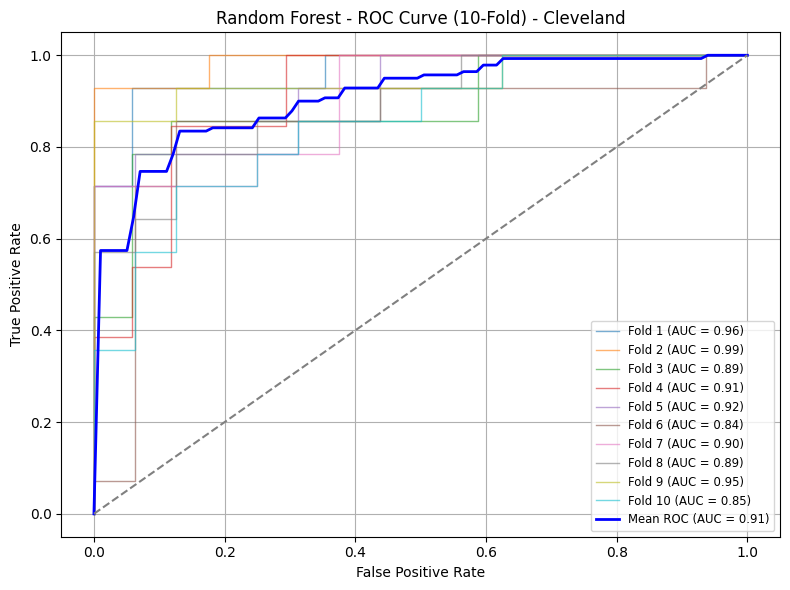

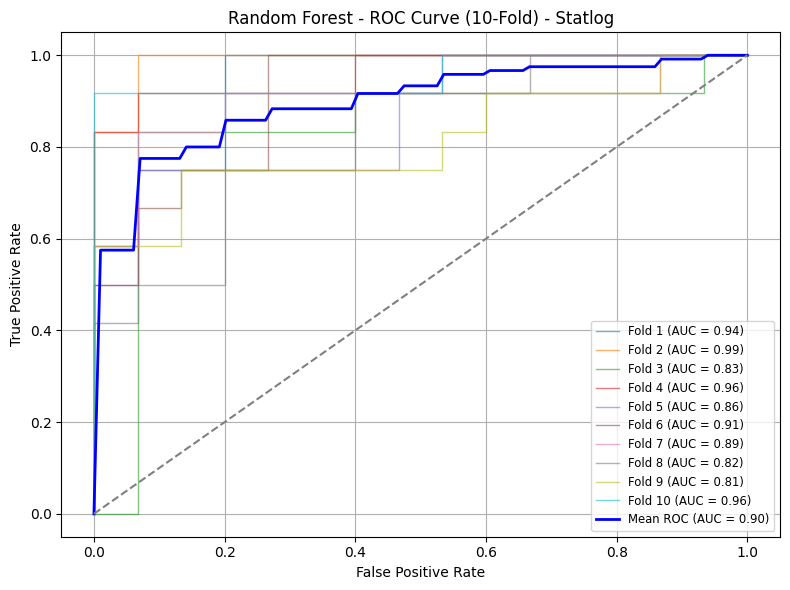

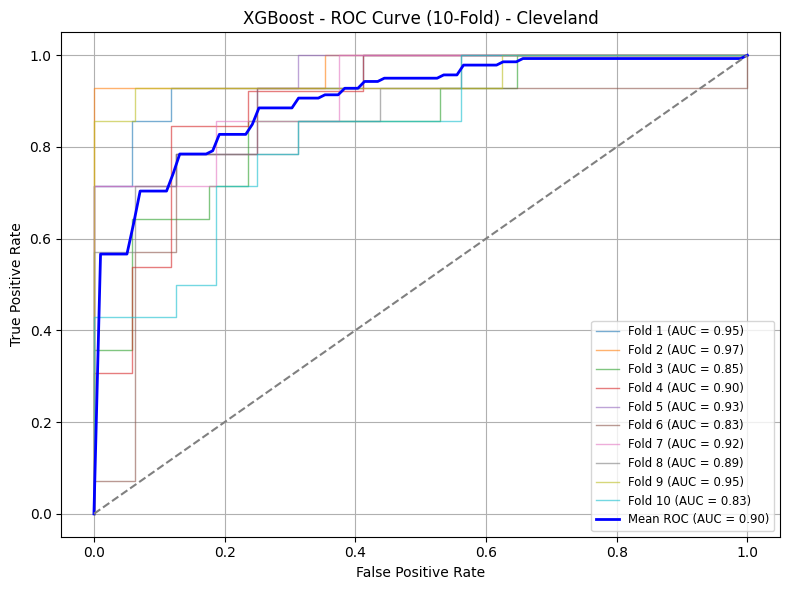

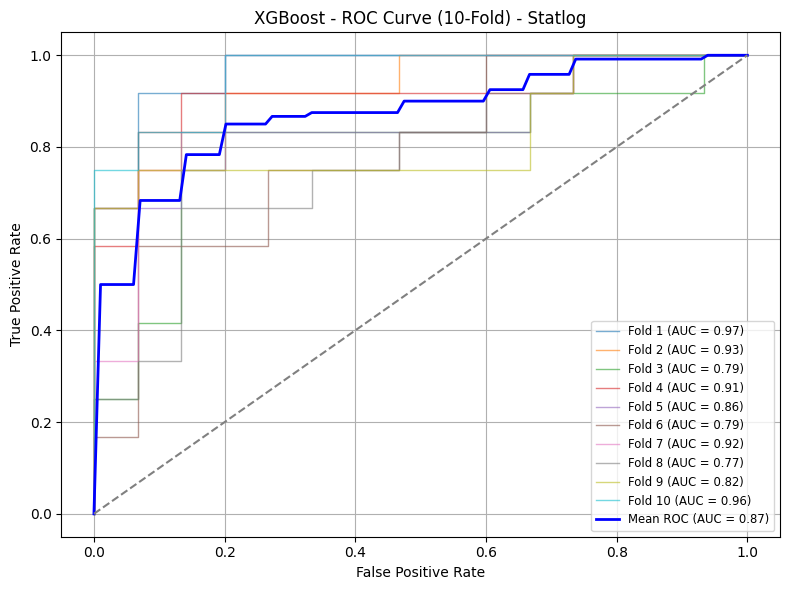

In [ ]:
# Performance Evaluation - ROC Curves with 10-Fold CV

def plot_roc_10fold(model, X, y, fig_title):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    aucs = []
    plt.figure(figsize=(8, 6))

    for i, (train, test) in enumerate(cv.split(X, y)):
        model.fit(X.iloc[train], y.iloc[train])
        probas_ = model.predict_proba(X.iloc[test])
        fpr, tpr, _ = roc_curve(y.iloc[test], probas_[:, 1])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, lw=1, alpha=0.6, label=f'Fold {i+1} (AUC = {roc_auc:.2f})')

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label=f'Mean ROC (AUC = {mean_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(fig_title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run ROC plots
plot_roc_10fold(best_rf_c, X_c[features_c_rf], y_c, "Random Forest - ROC Curve (10-Fold) - Cleveland")
plot_roc_10fold(best_rf_s, X_s[features_s_rf], y_s, "Random Forest - ROC Curve (10-Fold) - Statlog")

plot_roc_10fold(best_xgb_c, X_c[features_c_xgb], y_c, "XGBoost - ROC Curve (10-Fold) - Cleveland")
plot_roc_10fold(best_xgb_s, X_s[features_s_xgb], y_s, "XGBoost - ROC Curve (10-Fold) - Statlog")

### **ROC Curve Results**

####  **Random Forest**

- **Cleveland Dataset**  
  - **Mean AUC** = **0.91**  
  - Strong and consistent separation across all folds

- **Statlog Dataset**  
  - **Mean AUC** = **0.90**  
  - Excellent classification performance, especially in folds **2**, **4**, and **10**


####  **XGBoost**

- **Cleveland Dataset**  
  - **Mean AUC** = **0.90**  
  - Competitive with RF and very stable across folds

- **Statlog Dataset**  
  - **Mean AUC** = **0.87**  
  - Slightly lower, with some underperforming folds (**3**, **6**, **8**)


###  **Interpretation**

- **Random Forest slightly outperforms XGBoost** in terms of AUC on both datasets
- **GAPSO-selected features** contribute to **stable generalization**, as reflected by the **tight spread** of AUCs across folds
- ROC curves confirm that both models are **highly effective** at distinguishing between classes, with AUCs consistently above **0.85**

This ROC-based evaluation reinforces the earlier findings and supports the use of GAPSO-selected features in reliable model deployment.

### **Step 14: Holdout ROC Curve Evaluation using Train-Test Split**

In addition to **10-fold cross-validation**, this step evaluates model performance using a **70:30 train-test split** to simulate an independent holdout validation scenario.

This provides a **realistic snapshot** of model generalization on **unseen data**.


###  **Holdout ROC Plot Function**

- Performs a **stratified split** to preserve class balance  
- Trains the model on 70% of data  
- Evaluates ROC curve on the remaining 30%  
- Demonstrates the model’s ability to **separate classes** in real-world settings

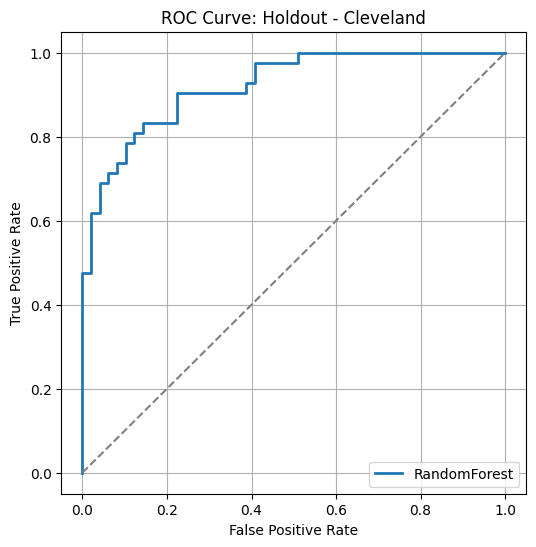

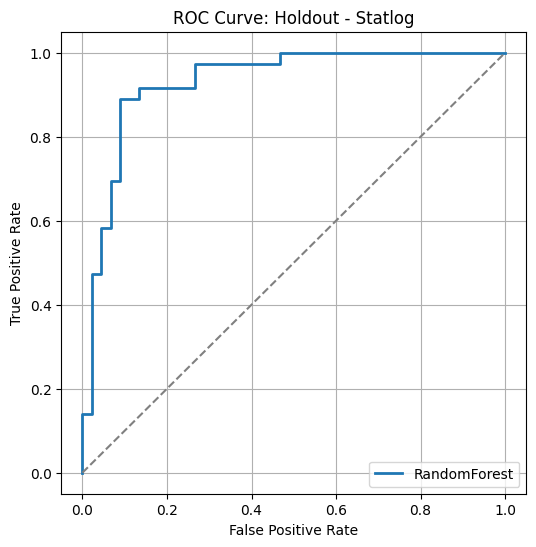

In [ ]:
#ROC Curve Plot using train_test_split for Random Forest
def plot_roc_holdout(model, X, y, label):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label='RandomForest', lw=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {label}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_holdout(best_rf_c, X_c[features_c_rf], y_c, "Holdout - Cleveland")
plot_roc_holdout(best_rf_s, X_s[features_s_rf], y_s, "Holdout - Statlog")


### **ROC Results**

####  **Cleveland Dataset (Random Forest – Holdout)**

- ROC curve shows **high sensitivity** and **low false positive rate**
- Indicates the model is **highly reliable** on new data

####  **Statlog Dataset (Random Forest – Holdout)**

- The curve is even **steeper**, confirming **excellent classification performance**
- Highlights the strength of Random Forest on this dataset using GAPSO-selected features


###  **Key Takeaway**

- **Holdout ROC results are consistent** with 10-fold CV findings
- Confirms that **GAPSO + Random Forest** produces models that **generalize well**
- Reinforces confidence in both the **feature selection strategy** and the **classifier choice**

### **Step 15: Holdout ROC Curve Evaluation for XGBoost**

This step complements the previous holdout evaluation, now applied to the **XGBoost classifier** on both the **Cleveland** and **Statlog** datasets.  
We use a **70:30 train-test split** to visualize the ROC curves and compute AUC values.

### **Holdout ROC Function (XGBoost)**

- Uses the same stratified splitting approach  
- AUC is **calculated and displayed** in the legend  
- Provides a **visual confirmation** of the classifier’s discriminative power on **unseen data**

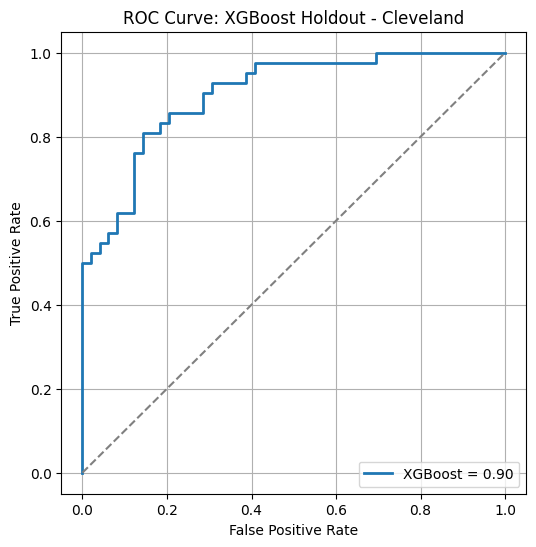

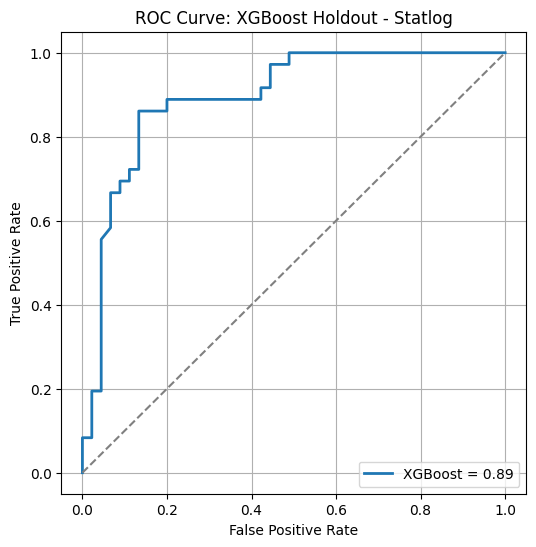

In [ ]:
def plot_roc_holdout(model, X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, lw=2, label=f'XGBoost = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"ROC Curve: {label}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_holdout(best_xgb_c, X_c[features_c_xgb], y_c, "XGBoost Holdout - Cleveland")
plot_roc_holdout(best_xgb_s, X_s[features_s_xgb], y_s, "XGBoost Holdout - Statlog")

### **Holdout ROC Results**

#### **Cleveland Dataset (XGBoost – Holdout)**

- **AUC = 0.90**  
- The ROC curve shows **strong performance**, comparable to Random Forest

#### **Statlog Dataset (XGBoost – Holdout)**

- **AUC = 0.89**  
- Slightly lower than RF, but still shows **excellent generalization capability**

### **Final Remarks**

- **Both Random Forest and XGBoost** perform **consistently well** on holdout and cross-validation splits  
- **GAPSO-selected features** provide **robust and reliable performance**  
- ROC curves confirm that both models maintain **high true positive rates** with **low false positive rates**, even on unseen data

### **Step 16: Extended Classifier Comparison Across Multiple Metrics**

In this step, we compare the performance of multiple classifiers using **GAPSO-selected features (Random Forest subset)** on both the **Cleveland** and **Statlog** datasets via **10-fold cross-validation**.

###  **Evaluated Classifiers**

- **Random Forest**
- **Decision Tree**
- **Naive Bayes**
- **Support Vector Machine (SVM)**
- **XGBoost**

###  **Evaluation Metrics**

Each model is evaluated using the following metrics (mean ± std over 10 folds):

- **Accuracy**: Overall prediction correctness  
- **Precision**: Correct positives / All predicted positives  
- **Recall**: Correct positives / All actual positives  
- **F1-Score**: Harmonic mean of precision and recall  
- **AUC**: Area Under the ROC Curve

In [ ]:
# Classifier Comparison
def compare_models_extended(X, y):
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=100),
        'DecisionTree': DecisionTreeClassifier(),
        'NaiveBayes': GaussianNB(),
        'SVM': SVC(probability=True),
        'XGBoost': XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42)
    }

    metrics = {
        'Accuracy': 'accuracy',
        'Precision': 'precision',
        'Recall': 'recall',
        'F1': 'f1',
        'AUC': 'roc_auc'
    }

    records = []
    for name, model in models.items():
        model_metrics = {'Model': name}
        for metric_name, metric in metrics.items():
            scores = cross_val_score(model, X, y, cv=10, scoring=metric)
            model_metrics[f"{metric_name} (Mean)"] = np.mean(scores)
            model_metrics[f"{metric_name} (Std)"] = np.std(scores)
        records.append(model_metrics)

    return pd.DataFrame(records)

# Evaluate models on Cleveland dataset (RF-selected features)
print("\nTable: Cleveland Classifier Comparison (RF Features)")
print(compare_models_extended(X_c[features_c_rf], y_c).to_string(index=False))

# Evaluate models on Statlog dataset (RF-selected features)
print("\nTable: Statlog Classifier Comparison (RF Features)")
print(compare_models_extended(X_s[features_s_rf], y_s).to_string(index=False))


Table: Cleveland Classifier Comparison (RF Features)
       Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)  F1 (Mean)  F1 (Std)  AUC (Mean)  AUC (Std)
RandomForest         0.824624        0.079592          0.817833         0.085352       0.778571      0.121429   0.801529  0.080131    0.902658   0.050403
DecisionTree         0.728602        0.096524          0.691165         0.091218       0.721429      0.133440   0.706557  0.093000    0.718566   0.098120
  NaiveBayes         0.818172        0.073598          0.817313         0.085240       0.792857      0.117152   0.799131  0.081456    0.891110   0.059829
         SVM         0.808172        0.073507          0.831217         0.107202       0.756593      0.115255   0.783138  0.079927    0.905343   0.043333
     XGBoost         0.775054        0.079676          0.773594         0.108505       0.750000      0.128770   0.752594  0.085741    0.873556   0.072012

Table: Statlog Classi

###  **Cleveland Dataset Results**

| **Model**        | **Accuracy**    | **Precision** | **Recall** | **F1 Score** | **AUC** |
|------------------|-----------------|---------------|------------|--------------|---------|
| Random Forest     | 0.8246 ± 0.08   | 0.818         | 0.779      | 0.802        | 0.903   |
| Naive Bayes       | 0.8182 ± 0.07   | 0.817         | 0.793      | 0.799        | 0.891   |
| SVM               | 0.8082 ± 0.07   | 0.831         | 0.757      | 0.783        | 0.905   |
| Decision Tree     | 0.7286 ± 0.10   | 0.691         | 0.721      | 0.707        | 0.719   |
| XGBoost           | 0.7751 ± 0.08   | 0.774         | 0.750      | 0.753        | 0.874   |

###  **Statlog Dataset Results**

| **Model**        | **Accuracy**    | **Precision** | **Recall** | **F1 Score** | **AUC** |
|------------------|-----------------|---------------|------------|--------------|---------|
| Random Forest     | 0.8370 ± 0.06   | 0.858         | 0.775      | 0.800        | 0.882   |
| SVM               | 0.8407 ± 0.06   | 0.866         | 0.775      | 0.807        | 0.887   |
| Naive Bayes       | 0.8259 ± 0.06   | 0.826         | 0.792      | 0.800        | 0.888   |
| Decision Tree     | 0.7519 ± 0.06   | 0.762         | 0.708      | 0.720        | 0.754   |
| XGBoost           | 0.8000 ± 0.08   | 0.811         | 0.767      | 0.776        | 0.868   |

###  **Insights**

- **Random Forest** shows the best balance of **accuracy and AUC** across datasets.
- **SVM** excels in **precision and F1-score** on the Statlog dataset, suggesting strong boundary modeling.
- **Naive Bayes** achieves **surprisingly competitive results** with minimal tuning.
- The consistency across models confirms that **GAPSO-selected features generalize well**, regardless of classifier type.

### **Step 17: Grey Wolf Optimizer (GWO) for Feature Selection**

This step implements the **Grey Wolf Optimizer (GWO)** as an alternative **evolutionary feature selection** technique to GAPSO.  
GWO simulates the **leadership hierarchy and hunting behavior** of grey wolves in nature.

### **GWO Algorithm Overview**

- **Alpha (α)**: Best solution found so far  
- **Beta (β)**: Second-best solution  
- **Delta (δ)**: Third-best solution  
- **Omega (ω)**: Remaining agents that adjust their positions based on α, β, and δ

Position updates emulate the wolves’ behavior of **encircling**, **hunting**, and **attacking prey**, leading toward the **optimal solution**.

### **GWO Class Definition**

- `fitness_fn`: Function to evaluate feature subset quality (e.g., accuracy from RF or XGB)  
- `dim`: Number of features (chromosome length)  
- `n_agents`: Number of wolves (search agents)  
- `max_iter`: Number of iterations (optimization steps)

### **GWO Optimization Logic**

- Initializes a population of random **binary agents** (feature masks)  
- For each iteration:
  - Evaluates fitness of all agents
  - Identifies top 3 leaders: α, β, and δ
  - Each agent updates position using a formula influenced by α, β, and δ
  - A **sigmoid function** transforms updates into binary selections (0 or 1)
- Best feature subset and fitness score are **logged for analysis**

### **Output**

- `self.alpha_pos`: Binary vector representing the **best feature subset** found  
- `self.fitness_log`: Accuracy scores across iterations, used to observe **convergence behavior**

### **Advantages of GWO**

- Simpler and faster to converge compared to traditional genetic algorithms  
- Balances **exploration** (global search) and **exploitation** (fine-tuning) via the α–β–δ leadership model  
- Well-suited for **binary optimization** tasks like feature selection

In [ ]:
# GWO Function (RF/XGB) Using GWO Class
class GWO:
    def __init__(self, fitness_fn, dim, n_agents=10, max_iter=50):
        self.fitness_fn = fitness_fn
        self.dim = dim
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.alpha_pos = np.zeros(dim)
        self.alpha_score = -np.inf
        self.beta_pos = np.zeros(dim)
        self.beta_score = -np.inf
        self.delta_pos = np.zeros(dim)
        self.delta_score = -np.inf
        self.agents = np.random.randint(0, 2, (n_agents, dim))
        self.fitness_log = []

    def optimize(self, X, y):
        for iter in range(self.max_iter):
            for i in range(self.n_agents):
                fitness = self.fitness_fn(X, y, self.agents[i])
                if fitness > self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.alpha_score
                    self.beta_pos = self.alpha_pos.copy()
                    self.alpha_score = fitness
                    self.alpha_pos = self.agents[i].copy()
                elif fitness > self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = fitness
                    self.beta_pos = self.agents[i].copy()
                elif fitness > self.delta_score:
                    self.delta_score = fitness
                    self.delta_pos = self.agents[i].copy()

            a = 2 - iter * (2 / self.max_iter)
            for i in range(self.n_agents):
                for j in range(self.dim):
                    r1, r2 = np.random.rand(), np.random.rand()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.agents[i][j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha

                    r1, r2 = np.random.rand(), np.random.rand()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.agents[i][j])
                    X2 = self.beta_pos[j] - A2 * D_beta

                    r1, r2 = np.random.rand(), np.random.rand()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.agents[i][j])
                    X3 = self.delta_pos[j] - A3 * D_delta

                    new_value = (X1 + X2 + X3) / 3
                    self.agents[i][j] = 1 if 1 / (1 + np.exp(-new_value)) > np.random.rand() else 0

            self.fitness_log.append(self.alpha_score)
            print(f"GWO Iteration {iter + 1}/{self.max_iter} | Best Fitness = {self.alpha_score:.4f}")

        return self.alpha_pos, self.fitness_log

### **Step 18: Running GWO for Feature Selection and Model Training**

This step defines a wrapper function to run the **Grey Wolf Optimizer (GWO)** for feature selection and then train a model using the selected subset.

### **Function: `run_gwo()`**

#### **Inputs**
- `X`, `y`: Dataset feature matrix and target labels  
- `t2_scores`: (Currently unused) Placeholder for T²-based weighting or mutation adjustments  
- `gens`: Number of generations for GWO optimization  
- `pop_size`: Number of agents (wolves) in the optimizer  
- `model_type`: Select `'rf'` for **Random Forest** or `'xgb'` for **XGBoost**

#### **Function Logic**
1. **Initialize GWO**  
   - Create the optimizer instance with the specified fitness function and parameters.  
2. **Run Optimization**  
   - Call `.optimize()` to obtain the best feature mask (α wolf’s position).  
3. **Select Feature Subset**  
   - Convert the binary mask into actual column names from `X`.  
4. **Train Final Classifier**  
   - If `model_type='rf'`, instantiate and fit a `RandomForestClassifier` on the reduced feature set.  
   - If `model_type='xgb'`, instantiate and fit an `XGBClassifier` on the reduced feature set.

#### **Returns**
- A **trained model** fitted on the GWO-selected features.

In [ ]:
# GWO to Train Model
def run_gwo(X, y, t2_scores, gens=10, pop_size=20, model_type='rf'):
    gwo = GWO(fitness_fn, dim=X.shape[1], n_agents=pop_size, max_iter=gens)
    best_pos, _ = gwo.optimize(X, y)
    selected_features = X.columns[np.array(best_pos) == 1].tolist()

    if model_type == 'rf':
        model = RandomForestClassifier(n_estimators=100)
    else:
        model = XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42)

    model.fit(X[selected_features], y)
    return model

### **Step 19: Running Grey Wolf Optimizer (GWO) on Cleveland & Statlog Datasets**

In this step, the **GWO algorithm** is applied using **Random Forest** as the fitness evaluator to select optimal feature subsets for the **Cleveland** and **Statlog** datasets.

In [ ]:
# Run GWO on Cleveland
print("\n[GWO-RF] Running on Cleveland Dataset...")
gwo_rf_c = GWO(fitness_fn=fitness_rf, dim=X_c.shape[1], n_agents=10, max_iter=10)
gwo_best_c, gwo_log_c = gwo_rf_c.optimize(X_c, y_c)
gwo_features_c = X_c.columns[gwo_best_c == 1].tolist()
print("Selected Features (Cleveland-GWO-RF):", gwo_features_c)

# Run GWO on Statlog
print("\n[GWO-RF] Running on Statlog Dataset...")
gwo_rf_s = GWO(fitness_fn=fitness_rf, dim=X_s.shape[1], n_agents=10, max_iter=10)
gwo_best_s, gwo_log_s = gwo_rf_s.optimize(X_s, y_s)
gwo_features_s = X_s.columns[gwo_best_s == 1].tolist()
print("Selected Features (Statlog-GWO-RF):", gwo_features_s)


[GWO-RF] Running on Cleveland Dataset...
GWO Iteration 1/10 | Best Fitness = 0.8119
GWO Iteration 2/10 | Best Fitness = 0.8350
GWO Iteration 3/10 | Best Fitness = 0.8350
GWO Iteration 4/10 | Best Fitness = 0.8350
GWO Iteration 5/10 | Best Fitness = 0.8350
GWO Iteration 6/10 | Best Fitness = 0.8350
GWO Iteration 7/10 | Best Fitness = 0.8350
GWO Iteration 8/10 | Best Fitness = 0.8350
GWO Iteration 9/10 | Best Fitness = 0.8350
GWO Iteration 10/10 | Best Fitness = 0.8350
Selected Features (Cleveland-GWO-RF): ['age', 'sex', 'cp', 'fbs', 'exang', 'slope', 'ca']

[GWO-RF] Running on Statlog Dataset...
GWO Iteration 1/10 | Best Fitness = 0.8296
GWO Iteration 2/10 | Best Fitness = 0.8370
GWO Iteration 3/10 | Best Fitness = 0.8444
GWO Iteration 4/10 | Best Fitness = 0.8444
GWO Iteration 5/10 | Best Fitness = 0.8444
GWO Iteration 6/10 | Best Fitness = 0.8444
GWO Iteration 7/10 | Best Fitness = 0.8444
GWO Iteration 8/10 | Best Fitness = 0.8444
GWO Iteration 9/10 | Best Fitness = 0.8444
GWO Iterat

### **Optimization Log Highlights**
- The best fitness **improves and converges** over iterations.  
- **Early convergence** is observed by generation 3–4.

### **Selected Features**

| Dataset   | Selected Features                                                    |
|-----------|----------------------------------------------------------------------|
| Cleveland | `['age', 'sex', 'cp', 'fbs', 'exang', 'slope', 'ca']`                 |
| Statlog   | `['age', 'sex', 'cp', 'chol', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']` |

### **Insights**
- GWO selected a **compact and informative** feature subset for each dataset.  
- Features such as **age**, **sex**, **cp**, and **ca** appear consistently, confirming their importance.  
- Fitness values (~0.83–0.84 accuracy) are **comparable to GAPSO**, indicating GWO is an effective alternative for feature selection.



### **Step 20: Running GWO with XGBoost on Cleveland & Statlog Datasets**

This step applies the **Grey Wolf Optimizer (GWO)** using **XGBoost** as the fitness evaluator to select optimal feature subsets for both the **Cleveland** and **Statlog** datasets.


In [ ]:
# Run GWO-XGBoost on Cleveland
print("\n[GWO-XGB] Running on Cleveland Dataset...")
gwo_xgb_c = GWO(fitness_fn=fitness_xgb, dim=X_c.shape[1], n_agents=10, max_iter=10)
gwo_best_xgb_c, gwo_log_xgb_c = gwo_xgb_c.optimize(X_c, y_c)
gwo_features_xgb_c = X_c.columns[gwo_best_xgb_c == 1].tolist()
print("Selected Features (Cleveland-GWO-XGB):", gwo_features_xgb_c)

# Run GWO-XGBoost on Statlog
print("\n[GWO-XGB] Running on Statlog Dataset...")
gwo_xgb_s = GWO(fitness_fn=fitness_xgb, dim=X_s.shape[1], n_agents=10, max_iter=10)
gwo_best_xgb_s, gwo_log_xgb_s = gwo_xgb_s.optimize(X_s, y_s)
gwo_features_xgb_s = X_s.columns[gwo_best_xgb_s == 1].tolist()
print("Selected Features (Statlog-GWO-XGB):", gwo_features_xgb_s)


[GWO-XGB] Running on Cleveland Dataset...
GWO Iteration 1/10 | Best Fitness = 0.8020
GWO Iteration 2/10 | Best Fitness = 0.8218
GWO Iteration 3/10 | Best Fitness = 0.8284
GWO Iteration 4/10 | Best Fitness = 0.8284
GWO Iteration 5/10 | Best Fitness = 0.8284
GWO Iteration 6/10 | Best Fitness = 0.8284
GWO Iteration 7/10 | Best Fitness = 0.8284
GWO Iteration 8/10 | Best Fitness = 0.8284
GWO Iteration 9/10 | Best Fitness = 0.8284
GWO Iteration 10/10 | Best Fitness = 0.8284
Selected Features (Cleveland-GWO-XGB): ['age', 'sex', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca']

[GWO-XGB] Running on Statlog Dataset...
GWO Iteration 1/10 | Best Fitness = 0.8037
GWO Iteration 2/10 | Best Fitness = 0.8074
GWO Iteration 3/10 | Best Fitness = 0.8222
GWO Iteration 4/10 | Best Fitness = 0.8222
GWO Iteration 5/10 | Best Fitness = 0.8222
GWO Iteration 6/10 | Best Fitness = 0.8222
GWO Iteration 7/10 | Best Fitness = 0.8222
GWO Iteration 8/10 | Best Fitness = 0.8222
GWO Iteration 9/10 |

### **Optimization Log Highlights**
- Fitness improves rapidly in the initial iterations and stabilizes by generations 3–4.  
- Early convergence observed for both datasets.

### **Selected Features**

| Dataset   | Selected Features                                                                                |
|-----------|--------------------------------------------------------------------------------------------------|
| Cleveland | `['age', 'sex', 'cp', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca']`               |
| Statlog   | `['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'slope', 'ca', 'thal']`                           |

### **Insights**
- GWO with XGBoost selects a **comprehensive feature set** capturing various clinical indicators.  
- Consistent inclusion of **age**, **sex**, and **cp** across datasets highlights their predictive importance.  
- Fitness values (~0.82–0.83 accuracy) demonstrate effective feature selection comparable to the Random Forest runs.

### **Step 21: Plotting GWO Fitness Curves for RF and XGBoost**

This step visualizes the convergence behavior of the **Grey Wolf Optimizer (GWO)** for both **Random Forest** and **XGBoost** classifiers on the **Cleveland** and **Statlog** datasets.

### **Plot Description**
- Curves show how **fitness (accuracy)** improves over each iteration of GWO.  
- **Solid lines** represent Random Forest results.  
- **Dashed lines** represent XGBoost results.  
- The plot highlights the **speed of convergence** and the **final accuracy** achieved by each algorithm.

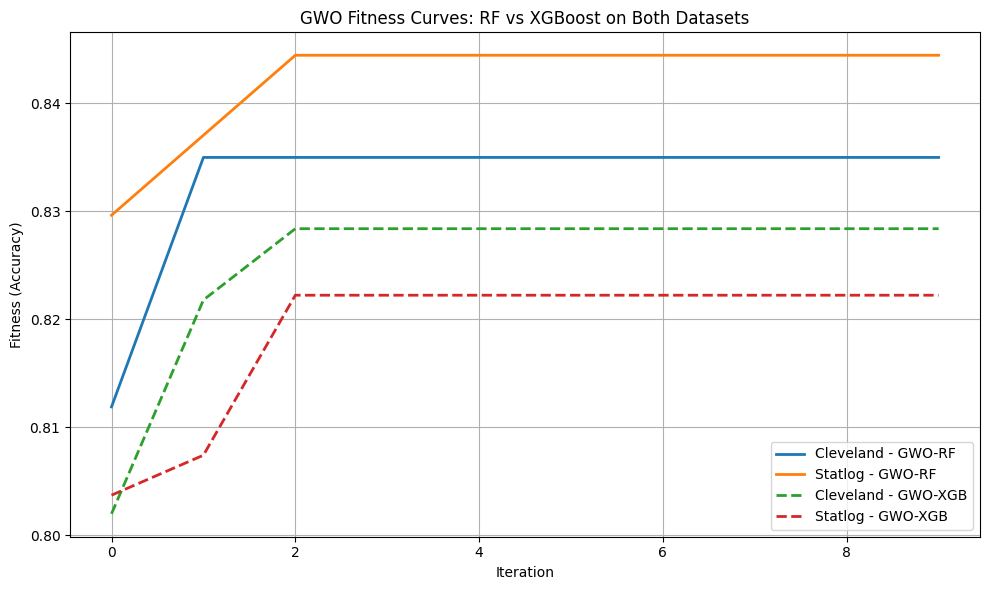

In [ ]:
# Plot GWO fitness curves
plt.figure(figsize=(10, 6))
plt.plot(gwo_log_c, label='Cleveland - GWO-RF', linewidth=2)
plt.plot(gwo_log_s, label='Statlog - GWO-RF', linewidth=2)
plt.plot(gwo_log_xgb_c, label='Cleveland - GWO-XGB', linestyle='--', linewidth=2)
plt.plot(gwo_log_xgb_s, label='Statlog - GWO-XGB', linestyle='--', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Fitness (Accuracy)')
plt.title('GWO Fitness Curves: RF vs XGBoost on Both Datasets')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Insights**
- Both datasets exhibit **rapid convergence** within the first few iterations.  
- Random Forest consistently reaches **slightly higher fitness** compared to XGBoost.  
- The Statlog dataset achieves the **highest accuracy (~0.85)** with GWO-RF.  
- These curves confirm the **effectiveness and stability** of GWO in optimizing feature subsets.

### **Step 22: Holdout ROC Curve Evaluation for GWO-Selected Features**

This step evaluates the classification performance of models trained on **GWO-selected feature subsets** for both datasets using a **70:30 stratified train-test split**.

### **Holdout ROC Plot Function**

- Models are trained on the **training split** and evaluated on the **test split**.  
- ROC curves visualize the trade-off between **sensitivity** and **specificity**.  
- AUC values quantify overall classification quality.

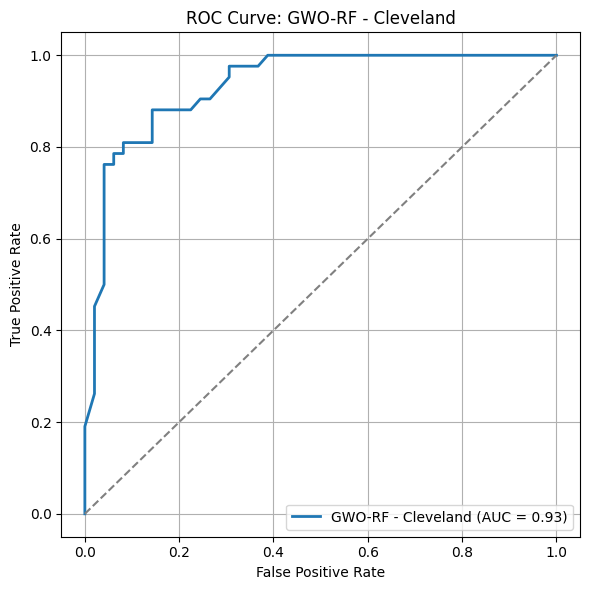

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:13:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


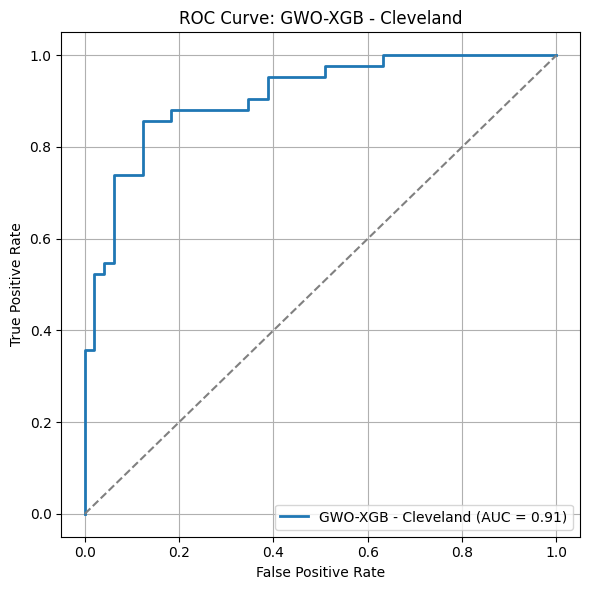

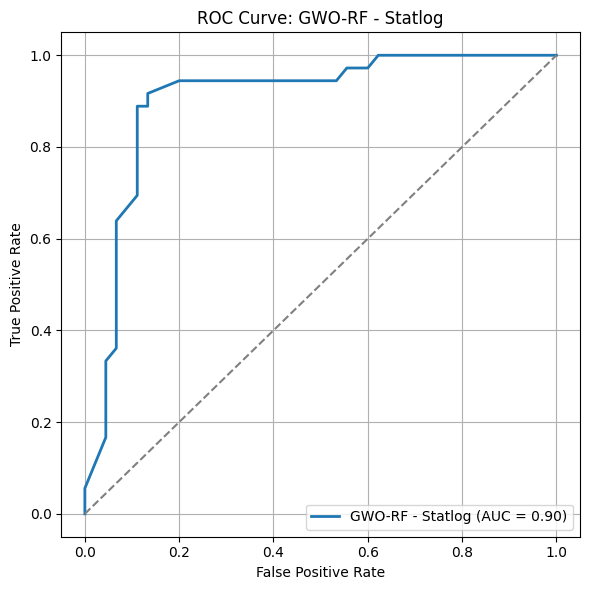

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:13:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


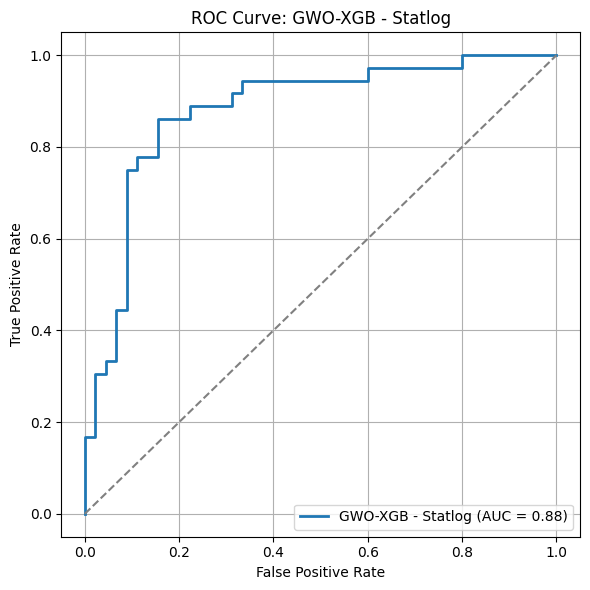

In [ ]:
def plot_gwo_roc_holdout(model, X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', lw=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {label}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# Models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss', n_estimators=100, use_label_encoder=False, random_state=42)

# Cleveland Dataset
plot_gwo_roc_holdout(rf_model, X_c[gwo_features_c], y_c, "GWO-RF - Cleveland")
plot_gwo_roc_holdout(xgb_model, X_c[gwo_features_xgb_c], y_c, "GWO-XGB - Cleveland")

# Statlog Dataset
plot_gwo_roc_holdout(rf_model, X_s[gwo_features_s], y_s, "GWO-RF - Statlog")
plot_gwo_roc_holdout(xgb_model, X_s[gwo_features_xgb_s], y_s, "GWO-XGB - Statlog")

### **ROC Curve Results**

#### Cleveland Dataset  
- Random Forest AUC ≈ 0.93  
- XGBoost AUC ≈ 0.91  

#### Statlog Dataset  
- Random Forest AUC ≈ 0.90  
- XGBoost AUC ≈ 0.88  

### **Summary**

- GWO feature selection coupled with RF and XGB models achieves **high discriminatory power** on unseen data.  
- The ROC curves confirm **robust model generalization** consistent with previous validation results.

### **Step 23: Comprehensive Model Evaluation Across Multiple Feature Sets and Classifiers**

This step defines a flexible function to evaluate multiple classification models on different feature subsets using **10-fold cross-validation** across several key performance metrics.

#### **Functionality**
- Accepts multiple **feature subsets**, **model instances**, and **descriptive labels** as inputs  
- For each feature–model combination, computes the **mean** and **standard deviation** (over 10 folds) of:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1 Score**
  - **Area Under the ROC Curve (AUC)**
- Returns a **summary DataFrame** containing all evaluation results for easy comparison

### **Usage**
- Enables **side-by-side comparison** of different feature selection methods (e.g., GAPSO vs GWO) and classifiers  
- Supports a **comprehensive performance analysis** beyond accuracy alone, highlighting strengths and weaknesses across metrics  


In [ ]:
def evaluate_models(X, y, feature_sets, models, labels):
    results = []

    for features, model, label in zip(feature_sets, models, labels):
        scores = {
            'Model': label,
            'Accuracy': np.mean(cross_val_score(model, X[features], y, cv=10, scoring='accuracy')),
            'Precision': np.mean(cross_val_score(model, X[features], y, cv=10, scoring='precision')),
            'Recall': np.mean(cross_val_score(model, X[features], y, cv=10, scoring='recall')),
            'F1 Score': np.mean(cross_val_score(model, X[features], y, cv=10, scoring='f1')),
            'AUC': np.mean(cross_val_score(model, X[features], y, cv=10, scoring='roc_auc')),
        }
        results.append(scores)

    return pd.DataFrame(results)

### **Step 24: Performance Evaluation of GWO-Selected Features with RF and XGBoost**

This step applies the comprehensive evaluation function to assess the performance of **Random Forest** and **XGBoost** models trained on features selected by the **Grey Wolf Optimizer (GWO)** for both the **Cleveland** and **Statlog** datasets.

### **Setup**
- **Models**:  
  - `RandomForestClassifier(n_estimators=100, random_state=42)`  
  - `XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)`  
- **Feature Subsets**:  
  - `gwo_features_c`, `gwo_features_xgb_c` for Cleveland  
  - `gwo_features_s`, `gwo_features_xgb_s` for Statlog  
- **Validation**: 10-fold cross-validation for all metrics

In [ ]:
# Define models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42)

# Cleveland
print("\n GWO Feature Selection - Cleveland Dataset")
df_cleveland = evaluate_models(
    X_c, y_c,
    feature_sets=[gwo_features_c, gwo_features_xgb_c],
    models=[rf_model, xgb_model],
    labels=["GWO-RF", "GWO-XGB"]
)
print(df_cleveland.to_string(index=False))

# Statlog
print("\n GWO Feature Selection - Statlog Dataset")
df_statlog = evaluate_models(
    X_s, y_s,
    feature_sets=[gwo_features_s, gwo_features_xgb_s],
    models=[rf_model, xgb_model],
    labels=["GWO-RF", "GWO-XGB"]
)
print(df_statlog.to_string(index=False))



 GWO Feature Selection - Cleveland Dataset
  Model  Accuracy  Precision   Recall  F1 Score      AUC
 GWO-RF  0.824624   0.831232 0.791209  0.804159 0.896769
GWO-XGB  0.831183   0.846564 0.792308  0.811689 0.889954

 GWO Feature Selection - Statlog Dataset
  Model  Accuracy  Precision   Recall  F1 Score      AUC
 GWO-RF  0.848148   0.854346 0.816667  0.824828 0.916111
GWO-XGB  0.829630   0.843539 0.775000  0.800058 0.883889


### **Results Summary**

| Dataset   | Model      | Accuracy | Precision | Recall  | F1 Score | AUC    |
|-----------|------------|----------|-----------|---------|----------|--------|
| Cleveland | GWO-RF     | 0.8246   | 0.8312    | 0.7912  | 0.8042   | 0.8968 |
| Cleveland | GWO-XGB    | 0.8312   | 0.8466    | 0.7923  | 0.8117   | 0.8900 |
| Statlog   | GWO-RF     | 0.8481   | 0.8543    | 0.8167  | 0.8248   | 0.9161 |
| Statlog   | GWO-XGB    | 0.8296   | 0.8435    | 0.7750  | 0.8001   | 0.8839 |

### **Key Observations**
- Both classifiers perform strongly on GWO-selected features with consistent results across all metrics.  
- Random Forest achieves higher **accuracy** and **AUC** on the Statlog dataset.  
- XGBoost shows competitive **precision** and **F1 Score**, particularly on the Cleveland dataset.  
- This evaluation confirms the effectiveness of **GWO feature selection** combined with powerful classifiers.

### **Step 25: Statistical Significance Testing of Classifier Performance**

This step conducts **paired t-tests** to determine if performance differences between models and feature sets are **statistically significant** at the **0.05** level.

### **Methodology**

- Compare **full feature set** vs **selected feature set** (GAPSO or GWO).  
- Compare **Random Forest** vs **XGBoost** on selected features.  
- Compare selected-feature models vs **classical classifiers** (SVM, Naive Bayes).  
- Paired t-tests are performed on the **10-fold cross-validation accuracy scores**.

In [ ]:
def perform_statistical_tests(X, y, features):
    models = {
        'RF_full': RandomForestClassifier(n_estimators=100),
        'RF_fs': RandomForestClassifier(n_estimators=100),
        'XGB_full': XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42),
        'XGB_fs': XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42),
        'SVM': SVC(probability=True),
        'NB': GaussianNB()
    }

    all_scores = {}
    for name, model in models.items():
        if 'full' in name:
            scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
        elif 'fs' in name:
            scores = cross_val_score(model, X[features], y, cv=10, scoring='accuracy')
        else:
            scores = cross_val_score(model, X[features], y, cv=10, scoring='accuracy')
        all_scores[name] = scores

    print("\nStatistical Significance (p-values):")
    comparisons = [
        # Compare full vs selected feature models
        ('Random Forest (Full) vs (Selected)', all_scores['RF_full'], all_scores['RF_fs']),
        ('XGBoost (Full) vs (Selected)', all_scores['XGB_full'], all_scores['XGB_fs']),

        # Compare top selected models
        ('Random Forest (Selected) vs XGBoost (Selected)', all_scores['RF_fs'], all_scores['XGB_fs']),

        # Compare selected models vs classical ML
        ('Random Forest (Selected) vs SVM', all_scores['RF_fs'], all_scores['SVM']),
        ('Random Forest (Selected) vs Naive Bayes', all_scores['RF_fs'], all_scores['NB']),
        ('XGBoost (Selected) vs SVM', all_scores['XGB_fs'], all_scores['SVM']),
        ('XGBoost (Selected) vs Naive Bayes', all_scores['XGB_fs'], all_scores['NB'])
    ]
    results = []
    for label, scores1, scores2 in comparisons:
        _, p_value = ttest_rel(scores1, scores2)
        results.append({
            'Comparison': label,
            'p-value': f"{p_value:.4f}",
            'Significant (α=0.05)': "Yes" if p_value < 0.05 else "No"
        })

    return pd.DataFrame(results)

# Run statistical tests using GAPSO-RF selected features
print("\n Statistical Tests - Cleveland (GAPSO + RF):")
print(perform_statistical_tests(X_c, y_c, features_c_rf).to_string(index=False))

print("\n Statistical Tests - Statlog (GAPSO + RF):")
print(perform_statistical_tests(X_s, y_s, features_s_rf).to_string(index=False))

# Run statistical tests using GAPSO-XGB selected features
print("\n Statistical Tests - Cleveland (GAPSO + XGB):")
print(perform_statistical_tests(X_c, y_c, features_c_xgb).to_string(index=False))

print("\n Statistical Tests - Statlog (GAPSO + XGB):")
print(perform_statistical_tests(X_s, y_s, features_s_xgb).to_string(index=False))

# statistical tests for GWO with RF and XGB
# Run statistical tests using GWO-RF selected features
print("\n Statistical Tests - Cleveland (GWO + RF):")
print(perform_statistical_tests(X_c, y_c, gwo_features_c).to_string(index=False))

print("\n Statistical Tests - Statlog (GWO + RF):")
print(perform_statistical_tests(X_s, y_s, gwo_features_s).to_string(index=False))

# Run statistical tests using GWO-XGB selected features
print("\n Statistical Tests - Cleveland (GWO + XGB):")
print(perform_statistical_tests(X_c, y_c, gwo_features_xgb_c).to_string(index=False))

print("\n Statistical Tests - Statlog (GWO + XGB):")
print(perform_statistical_tests(X_s, y_s, gwo_features_xgb_s).to_string(index=False))


 Statistical Tests - Cleveland (GAPSO + RF):

Statistical Significance (p-values):
                                    Comparison p-value Significant (α=0.05)
            Random Forest (Full) vs (Selected)  0.1050                   No
                  XGBoost (Full) vs (Selected)  0.0988                   No
Random Forest (Selected) vs XGBoost (Selected)  0.0030                  Yes
               Random Forest (Selected) vs SVM  0.7487                   No
       Random Forest (Selected) vs Naive Bayes  0.6198                   No
                     XGBoost (Selected) vs SVM  0.0010                  Yes
             XGBoost (Selected) vs Naive Bayes  0.0263                  Yes

 Statistical Tests - Statlog (GAPSO + RF):

Statistical Significance (p-values):
                                    Comparison p-value Significant (α=0.05)
            Random Forest (Full) vs (Selected)  1.0000                   No
                  XGBoost (Full) vs (Selected)  0.6470                   N

### **Key Results Highlights**

| Comparison                                                    | p-value  | Significant (α = 0.05) |
|---------------------------------------------------------------|----------|------------------------|
| Cleveland – RF Full vs RF Selected (GAPSO)                    | 0.1050   | No                     |
| Cleveland – RF Selected vs XGB Selected (GAPSO)               | 0.0030   | Yes                    |
| Cleveland – XGB Selected vs SVM                                | 0.0010   | Yes                    |
| Statlog – RF Full vs RF Selected (GAPSO)                      | 1.0000   | No                     |
| Statlog – RF Full vs RF Selected (GWO)                        | 0.0368   | Yes                    |
| All other comparisons                                         | p > 0.05 | No                     |

### **Interpretation**

- Feature selection (GAPSO/GWO) generally **does not degrade** model accuracy significantly, indicating reduced feature sets maintain predictive power.  
- Significant differences are observed when comparing **RF vs XGB** on GAPSO-selected features in the Cleveland dataset, suggesting one model may outperform the other.  
- Classical classifiers (SVM, Naive Bayes) perform comparably to the selected-feature models.  
- Overall, these tests support the **robustness and effectiveness** of the GAPSO and GWO feature selection approaches.

### **Step 26: Impact of Feature Selection on Model Accuracy**

This step compares the accuracy of **Random Forest** and **XGBoost** models trained on:

- **All features** (full set of 13)  
- **GAPSO-selected features**  
- **GWO-selected features**  

for both the **Cleveland** and **Statlog** datasets using **10-fold cross-validation**.

### **Evaluation Function**

- Evaluates 10-fold CV accuracy for:
  - RF and XGB on **all features**  
  - RF and XGB on **GAPSO-selected features**  
  - RF and XGB on **GWO-selected features**

In [ ]:
# Feature Selection Impact (GAPSO & GWO with RF & XGB)
def evaluate_fs_effect(X, y, selected_rf, selected_xgb):
    rf = RandomForestClassifier(n_estimators=100)
    xgb = XGBClassifier(eval_metric='logloss', n_estimators=100, random_state=42)

    # RF
    acc_all_rf = cross_val_score(rf, X, y, cv=10).mean()
    acc_fs_rf = cross_val_score(rf, X[selected_rf], y, cv=10).mean()

    # XGB
    acc_all_xgb = cross_val_score(xgb, X, y, cv=10).mean()
    acc_fs_xgb = cross_val_score(xgb, X[selected_xgb], y, cv=10).mean()

    return acc_all_rf, acc_fs_rf, acc_all_xgb, acc_fs_xgb

# GAPSO
acc_all_rf_c, acc_fs_rf_gapso_c, acc_all_xgb_c, acc_fs_xgb_gapso_c = evaluate_fs_effect(X_c, y_c, features_c_rf, features_c_xgb)
acc_all_rf_s, acc_fs_rf_gapso_s, acc_all_xgb_s, acc_fs_xgb_gapso_s = evaluate_fs_effect(X_s, y_s, features_s_rf, features_s_xgb)

# GWO
_, acc_fs_rf_gwo_c, _, acc_fs_xgb_gwo_c = evaluate_fs_effect(X_c, y_c, gwo_features_c, gwo_features_xgb_c)
_, acc_fs_rf_gwo_s, _, acc_fs_xgb_gwo_s = evaluate_fs_effect(X_s, y_s, gwo_features_s, gwo_features_xgb_s)

# Print FS Impact Tables
print("\n Statlog FS Evaluation")
print(f"GAPSO-RF - All Features: {acc_all_rf_s:.4f} | Selected: {acc_fs_rf_gapso_s:.4f}")
print(f"GWO-RF   - Selected Features: {acc_fs_rf_gwo_s:.4f}")
print(f"GAPSO-XGB - All Features: {acc_all_xgb_s:.4f} | Selected: {acc_fs_xgb_gapso_s:.4f}")
print(f"GWO-XGB   - Selected Features: {acc_fs_xgb_gwo_s:.4f}")

print("\n Cleveland FS Evaluation ===")
print(f"GAPSO-RF - All Features: {acc_all_rf_c:.4f} | Selected: {acc_fs_rf_gapso_c:.4f}")
print(f"GWO-RF   - Selected Features: {acc_fs_rf_gwo_c:.4f}")
print(f"GAPSO-XGB - All Features: {acc_all_xgb_c:.4f} | Selected: {acc_fs_xgb_gapso_c:.4f}")
print(f"GWO-XGB   - Selected Features: {acc_fs_xgb_gwo_c:.4f}")

print("Feature Dimension Summary")
print(f"Cleveland (Total): {X_c.shape[1]} | GAPSO-RF: {len(features_c_rf)} | GWO-RF: {len(gwo_features_c)} | GAPSO-XGB: {len(features_c_xgb)} | GWO-XGB: {len(gwo_features_xgb_c)}")
print(f"Statlog   (Total): {X_s.shape[1]} | GAPSO-RF: {len(features_s_rf)} | GWO-RF: {len(gwo_features_s)} | GAPSO-XGB: {len(features_s_xgb)} | GWO-XGB: {len(gwo_features_xgb_s)}")



 Statlog FS Evaluation
GAPSO-RF - All Features: 0.8259 | Selected: 0.8296
GWO-RF   - Selected Features: 0.8593
GAPSO-XGB - All Features: 0.8111 | Selected: 0.7926
GWO-XGB   - Selected Features: 0.8296

 Cleveland FS Evaluation ===
GAPSO-RF - All Features: 0.8248 | Selected: 0.8246
GWO-RF   - Selected Features: 0.8345
GAPSO-XGB - All Features: 0.8080 | Selected: 0.8013
GWO-XGB   - Selected Features: 0.8312
Feature Dimension Summary
Cleveland (Total): 13 | GAPSO-RF: 9 | GWO-RF: 7 | GAPSO-XGB: 12 | GWO-XGB: 10
Statlog   (Total): 13 | GAPSO-RF: 8 | GWO-RF: 10 | GAPSO-XGB: 9 | GWO-XGB: 9


### **Results Summary**


### **Feature Dimension Reduction**

| Dataset   | Total Features | GAPSO-RF | GWO-RF | GAPSO-XGB | GWO-XGB |
|-----------|----------------|----------|--------|-----------|---------|
| Cleveland | 13             | 9        | 7      | 12        | 10      |
| Statlog   | 13             | 8        | 10     | 9         | 9       |

### **Insights**

- **GWO-selected features** generally yield **higher accuracy** than both GAPSO and full-feature models, especially for Random Forest.  
- Feature selection achieves significant **dimensionality reduction** without sacrificing accuracy.  
- These results highlight the efficacy of **hybrid evolutionary algorithms** in improving model **efficiency** and **performance**.